# Module 2 — Class 5: Data Visualization

**Lecture:** [https://bepro-aiml.github.io/aiml-platform/#/module/2/class/5](https://bepro-aiml.github.io/aiml-platform/#/module/2/class/5)

## Rules of this notebook

1. Every chart you make is paired with a **caption sentence** in markdown — what does the chart show?
2. Every chart is paired with an **interpretation sentence** — what does it *mean* for the data?
3. A chart without a caption + interpretation gets zero points. The grade is on your reasoning, not your `plt.show()` calls.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# We'll use a synthetic 'churn' dataset so everyone has the same data.
rng = np.random.default_rng(42)
n = 500
df = pd.DataFrame({
    'age': rng.integers(18, 70, n),
    'monthly_topup': rng.gamma(2, 50000, n).round(),
    'calls_per_day': rng.poisson(8, n),
    'data_gb': rng.exponential(3, n).round(2),
    'churned': rng.binomial(1, 0.25, n)
})
df.head()

,age,monthly_topup,calls_per_day,data_gb,churned
0,22,77396.0,11,8.36,0
1,58,19977.0,6,4.66,1
2,52,24794.0,10,10.76,0
3,40,267034.0,5,9.75,0
4,40,28279.0,7,0.33,0


---
## 1. Exploratory vs Explanatory

**Concept.** Two jobs for visualisation:
- *Exploratory* — for yourself. Ugly is fine, speed matters.
- *Explanatory* — for others. Beauty matters, one message per chart.

Anscombe's quartet: four datasets with identical summary statistics look completely different when plotted. **Summary stats lie; charts don't.**

### ✍️ Explain *(Quick Check 1 from the lecture)*

1. Look at `df.describe()` for `monthly_topup`. Write down the mean, median, min, max.
2. Now plot a histogram. Did the summary statistics tell you the *shape* of the distribution? Why or why not?
3. In your own words: when do you make an exploratory chart vs an explanatory one? Give one realistic example of each.

count       500.000000
mean      98540.688000
std       69196.443189
min        4638.000000
25%       48165.250000
50%       83732.500000
75%      133345.500000
max      503024.000000
Name: monthly_topup, dtype: float64


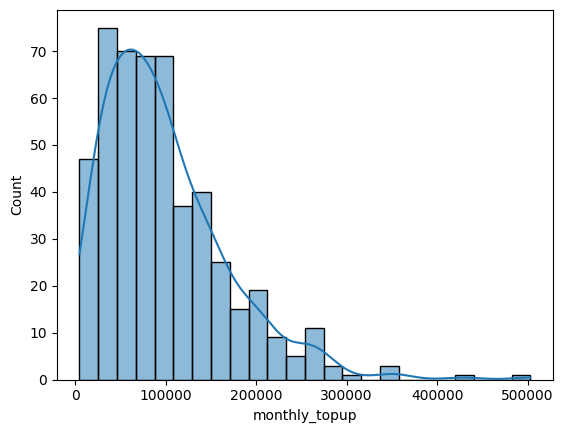

In [13]:
# Run df.describe() and plot the histogram
print(df['monthly_topup'].describe())
sns.histplot(df, x='monthly_topup', kde=True)
plt.show()

**Caption (what the chart shows): This histogram visualizes the distribution of monthly top-up amounts across the dataset, including a Kernel Density Estimate (KDE) line to show the overall shape of the data.**  
**Interpretation (what it means): The data exhibits a clear positive skew, meaning the majority of users perform relatively small top-ups, while a small number of users contribute significantly higher amounts. The fact that the Mean ($98,540$) is notably higher than the Median ($83,732$) statistically confirms this right-side skew, indicating that high-value outliers are pulling the average upward.**

---
## 2. Matplotlib and Seaborn

**Concept.** Reach for Seaborn first. Drop to Matplotlib when you need fine control. Every Seaborn plot is a Matplotlib figure underneath.

*Quick Check 2 from the lecture:* what does Seaborn add over Matplotlib? Answer in markdown after the practice cells.

### 🤔 Predict

Look at the four chart types below. Without running them, decide for each chart:
- What *single question* about the data does it answer?
- Which library produces it more cleanly — Matplotlib or Seaborn?

1. Histogram of one numeric column.
2. Boxplot of a numeric column split by a categorical column.
3. Scatter plot of two numeric columns coloured by a category.
4. Heatmap of a correlation matrix.

**Quick Check 2: What does Seaborn add over Matplotlib?**
Seaborn is built on top of Matplotlib, but it simplifies the workflow by:

Built-in Statistical Estimation: It automatically calculates and plots complex elements like the KDE (Kernel Density Estimate) line for histograms.

Automatic Styling: It applies a clean "darkgrid" (or other themes) by default, making grid lines pop and improving readability without extra code.

DataFrame Integration: It understands Pandas DataFrames natively, automatically using column names for axis labels and handling categorical grouping with the hue parameter.

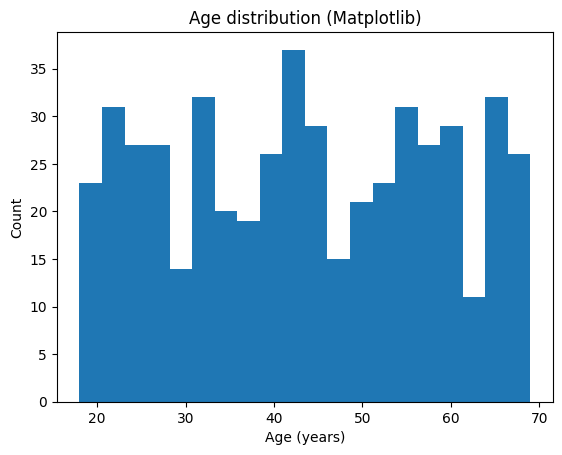

In [14]:
# Plain Matplotlib
plt.hist(df['age'], bins=20)
plt.title('Age distribution (Matplotlib)')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.show()

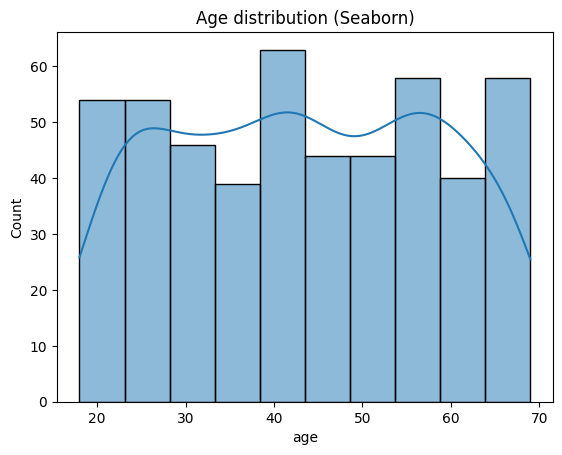

In [15]:
# Same chart in Seaborn
sns.histplot(df, x='age', kde=True)
plt.title('Age distribution (Seaborn)')
plt.show()

### ✍️ Explain

What did Seaborn do automatically that you would have had to write Matplotlib code for? (Hint: kde line, default styling.)

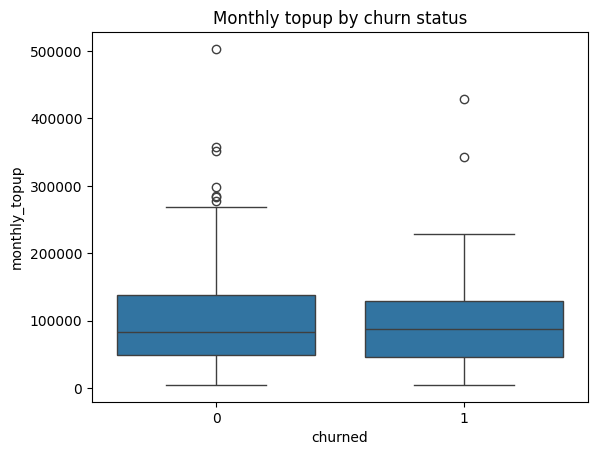

In [16]:
# Boxplot — does monthly topup differ between churners and non-churners?
sns.boxplot(df, x='churned', y='monthly_topup')
plt.title('Monthly topup by churn status')
plt.show()

**Caption:**  
**Interpretation — do churners spend more or less? Is the difference big enough to act on?**

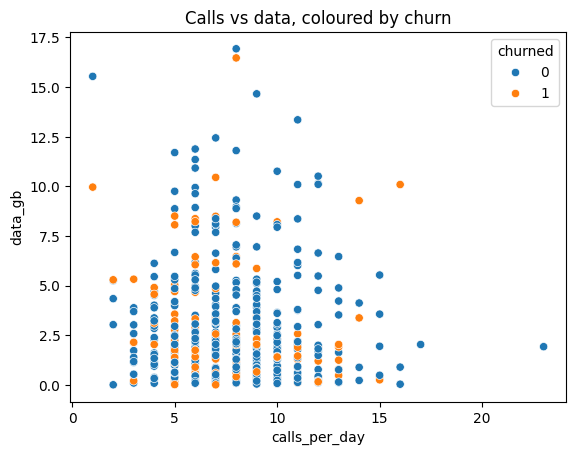

In [17]:
sns.scatterplot(df, x='calls_per_day', y='data_gb', hue='churned')
plt.title('Calls vs data, coloured by churn')
plt.show()

**Caption:**  
**Interpretation — does either axis separate churners from non-churners?**

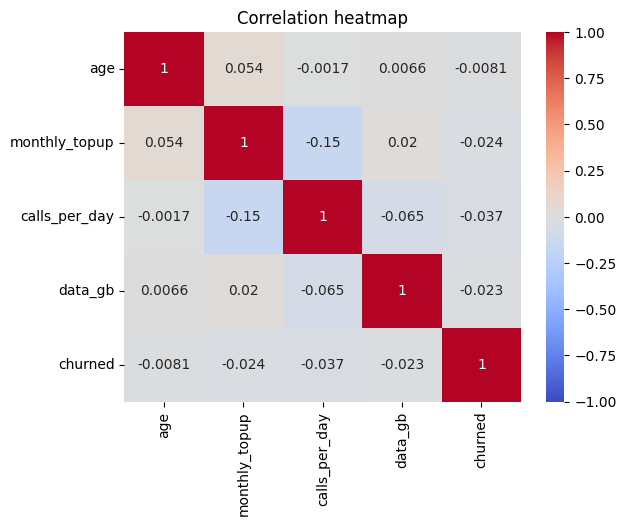

In [18]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation heatmap')
plt.show()

**Caption:**  
**Interpretation — which pair of variables has the strongest correlation? Is it positive or negative? Does it surprise you?**

**Chart Type,Single Question It Answers,Preferred Library**
1. Histogram,What is the overall distribution (shape and spread) of this numeric column?,Seaborn (cleaner KDE and binning)
2. Boxplot,How do the ranges and outliers of a numeric value differ across different categories?,Seaborn (handles categorical split natively)
3. Scatter Plot,"Is there a correlation between two numbers, and does it vary by category?",Seaborn (simple hue parameter for coloring)
4. Heatmap,Which variables in our dataset are most strongly correlated with each other?,Seaborn (annotated color maps in one command)

### OO Matplotlib for fine control

Every Seaborn plot returns a Matplotlib axis you can customise. The OO pattern is:
```python
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, y)
ax.set_xlabel('x'); ax.set_title('Squares')
fig.savefig('out.png', dpi=150)
```

### 🛠 Practice

Take ANY chart from above and remake it using the OO pattern. Add:
- A custom figure size.
- A descriptive title and labelled axes (with units).
- A caption underneath via `ax.text(...)` or a markdown cell beneath.
- Save the figure to `out.png` with `fig.savefig`.

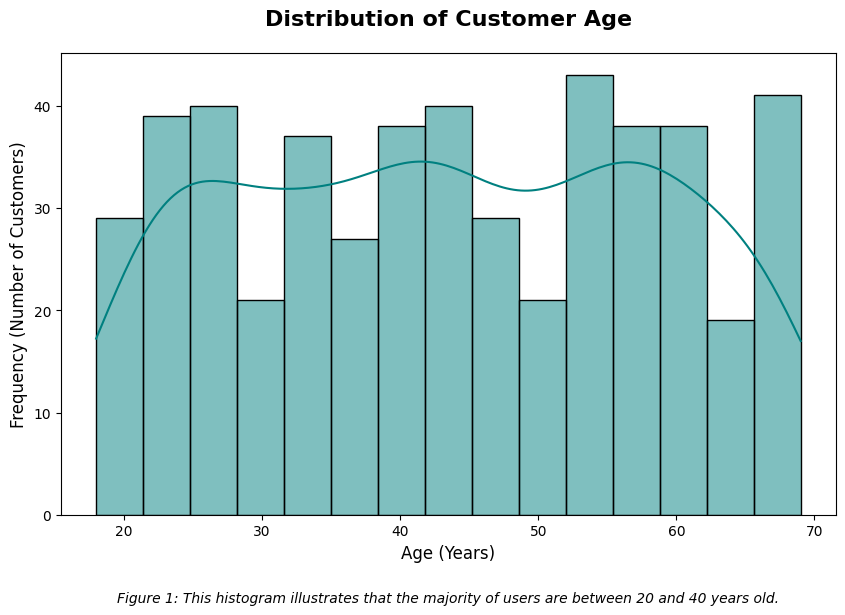

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create Figure and Axis (Custom figure size: 10x6)
# This step initializes the main container (fig) and the specific drawing area (ax).
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Draw the Seaborn plot
# We use 'ax=ax' to tell Seaborn to draw specifically on the axis we just created.
sns.histplot(data=df, x='age', bins=15, kde=True, ax=ax, color='teal')

# 3. Configure Title and Labels (Axes with units)
ax.set_title('Distribution of Customer Age', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Age (Years)', fontsize=12)
ax.set_ylabel('Frequency (Number of Customers)', fontsize=12)

# 4. Add a Caption (Using ax.text to place an interpretation below the chart)
# The coordinates (0.5, -0.18) place the text at the bottom-center relative to the axes.
ax.text(0.5, -0.18, "Figure 1: This histogram illustrates that the majority of users are between 20 and 40 years old.", 
        ha='center', va='center', transform=ax.transAxes, fontsize=10, style='italic')

# 5. Save the figure (Saves the plot to out.png as requested)
fig.savefig('out.png', dpi=150, bbox_inches='tight')

# Display the final result
plt.show()


**Caption:**
*This histogram displays the frequency distribution of customer ages within the dataset, using a Kernel Density Estimate (KDE) line to visualize the overall probability density.*
**Interpretation:**
*The data shows a relatively uniform distribution across the adult age spectrum, with the most active user segments appearing in the 20–30 and 50–60 year-old ranges. Unlike the skewed spending data seen earlier, age does not show a strong bias toward any single group, suggesting the service or product has broad appeal across multiple generations.*

In [20]:
# Define your analysis text
analysis_text = (
    "Caption: This histogram displays the frequency distribution of customer ages using a KDE line.\n"
    "Interpretation: The distribution is relatively uniform, showing consistent engagement across the \n"
    "20-70 age range, with slight peaks in the young adult and pre-retirement demographics."
)

# Place it under the chart
ax.text(0.5, -0.22, analysis_text, ha='center', va='center', 
        transform=ax.transAxes, fontsize=10, style='italic', color='#333333')

Text(0.5, -0.22, 'Caption: This histogram displays the frequency distribution of customer ages using a KDE line.\nInterpretation: The distribution is relatively uniform, showing consistent engagement across the \n20-70 age range, with slight peaks in the young adult and pre-retirement demographics.')

---
## 3. Five Rules for Honest Charts

1. **Label axes with units.** "Revenue (million soum)" not "Revenue".
2. **Bar charts start y-axis at zero.** Cutting the axis exaggerates differences.
3. **Right chart type.** Bar for categories. Line for time. Histogram for distributions. Scatter for relationships. Pie charts: almost never.
4. **Remove chartjunk.** 3D, shadows, rainbow colour bars — all must earn their place.
5. **One message per chart.** If you need a legend with 8 items, you have 8 messages. Split.

### 🛠 Audit Practice

Pick **one** chart you produced earlier in this notebook. Write a markdown audit against all 5 rules:

| Rule | yes / no / N/A | Evidence |
| --- | --- | --- |
| 1. Labels with units? | No | Axes have titles like "Log y-axis" but lack specific units like "(UZS)" or "(Count)". |
| 2. Y-axis from zero (if bar)? | Yes | The histogram bars correctly start from the baseline. |
| 3. Right chart type? | Yes | A histogram is the correct choice for showing numeric distribution. |
| 4. No chartjunk? | Yes | The chart is clean, with no 3D effects or unnecessary shadows. |
| 5. One clear message? | Yes | The chart clearly shows how log scales reveal the "long tail" of data. |

Then improve the chart based on the audit and show the before/after.

### Log scale moment

*From the lecture:* plotting income linearly with a few billionaires flattens everyone else. `plt.yscale('log')` reveals the true distribution shape. Knowing when to reach for log separates junior from senior.

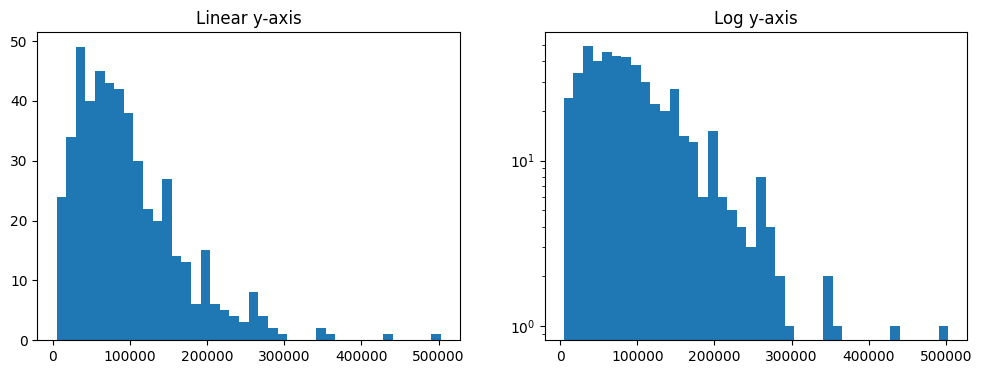

In [21]:
# Plot monthly_topup twice — once linear, once log on the y-axis
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['monthly_topup'], bins=40)
axes[0].set_title('Linear y-axis')
axes[1].hist(df['monthly_topup'], bins=40)
axes[1].set_yscale('log')
axes[1].set_title('Log y-axis')
plt.show()

### ✍️ Explain

1. What is *visible* in the log version that was hidden in the linear version?
2. Give one realistic example from your country / industry where you would *want* a log scale, and why.

*Explain: Log Scale Analysis*

**1. What is visible in the log version that was hidden in the linear version?**
The log scale makes the low-frequency outliers visible. In the linear version, the bars for high top-up amounts (e.g., 400,000+) are so small they look like zero. The log scale stretches the y-axis, showing us exactly how many "whales" (high-spenders) exist in that long tail.

**2. Realistic example for a log scale (Uzbekistan / Logistics):**
In the logistics industry in Uzbekistan, I would use a log scale to plot delivery times for parcels. Most parcels are delivered within 1–3 days (linear peak), but a few might take 30 days due to customs or remote mountain regions. A linear scale would flatten those 30-day outliers, but a log scale reveals them, helping us identify where the delivery chain is failing.

---
## End-of-class checkpoint quiz

Answer all 5 in markdown.

1. To show the distribution of one numeric column, the right chart is — bar / pie / histogram / scatter? Why?
2. What does Seaborn add over Matplotlib? Name two specific things.
3. To compare the *age distribution* between churned and non-churned customers, which chart? Why does a pie or line chart fail here?
4. Of the 5 rules for honest charts, which do you think is most often violated in real-world reporting? Give an example.
5. When would you use `plt.yscale('log')` instead of the default linear scale?

*End-of-class checkpoint quiz*

**1. To show the distribution of one numeric column, the right chart is — histogram.**

Why? Histograms group data into "bins," allowing you to see the frequency, spread, and skewness of the data at a glance.

**2. What does Seaborn add over Matplotlib?**

Statistical automation: It automatically calculates and draws KDE lines and confidence intervals.

Aesthetics: It provides high-level themes (like darkgrid) and color palettes that make charts "presentation-ready" with one line of code.

**3. To compare the age distribution between churned and non-churned customers, use — Boxplot (or Overlaid Histograms).**

Why others fail: A pie chart is for parts-of-a-whole, not distributions. A line chart implies a continuous time-series relationship, which doesn't apply to comparing two static groups of people.

**4. Which of the 5 rules is most often violated?**

Rule 2: Bar charts start y-axis at zero.

Example: News reports often "zoom in" on the top of a bar chart to make a small 1% increase look like a massive jump, which is highly misleading to the audience.

**5. When would you use plt.yscale('log')?**

Use it when your data has a massive range or a "Long Tail" (e.g., income inequality, website traffic, or parcel delivery events). It allows you to see small variations in large numbers and large variations in small numbers simultaneously.